Define 3-5 simple rules

In [1]:
from numpy.linalg import norm
from rulebook_benchmark.rulebook import Rulebook, Rule
from rulebook_benchmark.runner import run_scenic_metadrive

/Users/ekin/Scenic/src/scenic/core/errors.py:271: UserWarning: unable to install sys.excepthook to format Scenic backtraces
  warnings.warn("unable to install sys.excepthook to format Scenic backtraces")


In [2]:
def simple_vehicle_collision(handler, step): # simple collision rule that punishes the number of collisions with other vehicles at each step
    pool = handler(step)
    return len(pool.vehicles_colliding) # each pool and vehicles_colliding is cached, so they will not be recomputed if called multiple times over many rules
    # alternatively, we can directly compute the collisions by using the built-in colliding() method, which is not cached    
    vehicle_states = pool.vehicle_states
    return len(pool.colliding(vehicle_states))

def simple_vehicle_collision_with_timeline(handler,step):
    collision_timeline = handler.collision_timeline # stores (start, end) of each collision in the form timeline[uid] = [(start1, end1), (start2, end2), ...]
    # collision_timeline is cached, so it will not be recomputed if called multiple times over many rules
    # to avoid punishing the same collision multiple times, we can directly punish new collisions at each step
    vehicle_uids = handler.vehicle_uids
    new_collisions = 0
    for uid in vehicle_uids:
        uid_collisions = collision_timeline.get(uid, [])
        for start, end in uid_collisions:
            if start == step: # new collision starting at this step
                new_collisions += 1
    
    return new_collisions


def simple_vehicle_clearance(handler, step, threshold): # simple clearance rule that punishes the number of vehicles within a certain distance threshold at each step
    pool = handler(step)
    return len(pool.in_proximity(pool.ego_state, pool.vehicle_states, threshold))



def simple_speed_limit(handler, step, speed_limit): # simple speed limit rule that punishes the ego vehicle if its speed exceeds the speed limit at each step
    pool = handler(step)
    ego_velocity = pool.ego_state.velocity
    ego_speed = norm(ego_velocity)
    return 1 if ego_speed > speed_limit else 0

INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


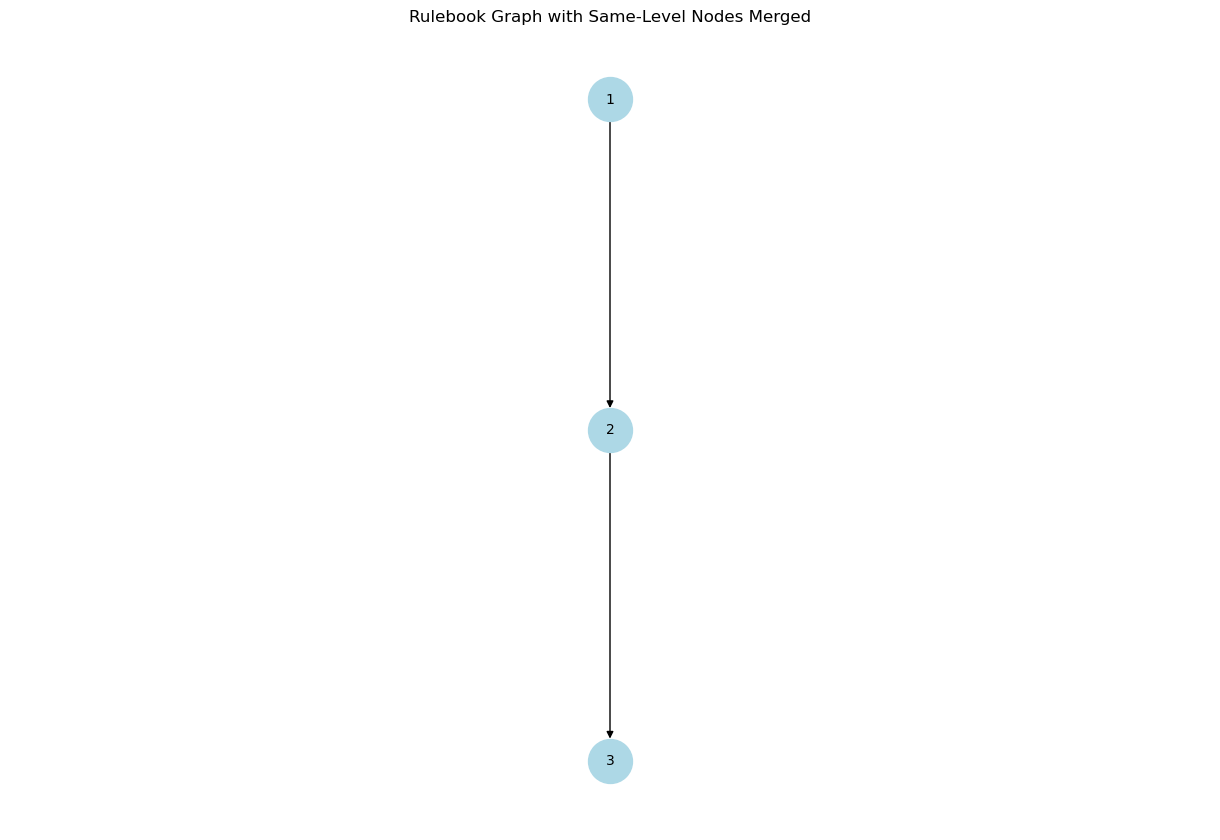

In [3]:
collision_rule = Rule(simple_vehicle_collision, aggregation_method=sum, name="simple_vehicle_collision", rule_id=1)
collision_timeline_rule = Rule(simple_vehicle_collision_with_timeline, aggregation_method=sum, name="simple_vehicle_collision_with_timeline", rule_id=1)
clearance_rule = Rule(simple_vehicle_clearance, aggregation_method=sum, name="simple_vehicle_clearance", rule_id=2)
speed_limit_rule = Rule(simple_speed_limit, aggregation_method=sum, name="simple_speed_limit", rule_id=3)

rule_id_to_rule = {collision_rule.id: collision_rule, clearance_rule.id: clearance_rule, speed_limit_rule.id: speed_limit_rule}
rule_id_to_rule_2 = {collision_timeline_rule.id: collision_timeline_rule, clearance_rule.id: clearance_rule, speed_limit_rule.id: speed_limit_rule}
rulebook = Rulebook(rule_id_to_rule=rule_id_to_rule, rulebook_file="tutorial_rulebook.graph")
rulebook.visualize_rulebook(save=False)

In [ ]:
from rulebook_benchmark.runner import run_scenic_metadrive
realization = run_scenic_metadrive(scenic_path = "tutorial.scenic", max_steps=100)

AttributeError: 'NoneType' object has no attribute 'attrib'

Create rulebook

Run scenario and run evaluation flow

Visualize scenario and violations

Import premade rules

Visualize scenario and violations

1 example sample from reasonable crowds to show how to compare trajectories

Falsification